In [60]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

In [61]:
# Diretórios e Configurações
OUTPUT_DIR = '../../data/output'
RECONSTRUCT_DIR = '../../data/reconstruct'
os.makedirs(RECONSTRUCT_DIR, exist_ok=True)

# Configurações do Mel-Spectrograma
SAMPLE_RATE = 22050
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

In [62]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {DEVICE}")

Treinando no dispositivo: cuda


In [63]:
# Carregar Dados
input_train = np.load(os.path.join(OUTPUT_DIR, 'train_input.npy'))
input_val = np.load(os.path.join(OUTPUT_DIR, 'val_input.npy'))
input_test = np.load(os.path.join(OUTPUT_DIR, 'test_input.npy'))

target_train = np.load(os.path.join(OUTPUT_DIR, 'train_target.npy'))
target_val = np.load(os.path.join(OUTPUT_DIR, 'val_target.npy'))
target_test = np.load(os.path.join(OUTPUT_DIR, 'test_target.npy'))



In [64]:
# Alteração: Normalização convertendo de dB para potência
input_train = librosa.db_to_power(input_train)
target_train = librosa.db_to_power(target_train)
input_val = librosa.db_to_power(input_val)
target_val = librosa.db_to_power(target_val)
input_test = librosa.db_to_power(input_test)
target_test = librosa.db_to_power(target_test)

In [65]:
# Normalizar os dados
input_train /= np.max(input_train)
target_train /= np.max(target_train)
input_val /= np.max(input_val)
target_val /= np.max(target_val)
input_test /= np.max(input_test)
target_test /= np.max(target_test)

In [66]:
# Dataset Personalizado
class SpectrogramDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.float32).unsqueeze(0)  # [1, H, W]
        y = torch.tensor(self.targets[idx], dtype=torch.float32).unsqueeze(0)  # [1, H, W]
        return x, y

train_dataset = SpectrogramDataset(input_train, target_train)
val_dataset = SpectrogramDataset(input_val, target_val)
test_dataset = SpectrogramDataset(input_test, target_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=1)


In [67]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        # Encoder
        self.encoder1 = self.conv_block(1, 64)  # Entrada com 1 canal
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)

        # Pooling
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.conv_block(256, 512)

        # Decoder
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = self.conv_block(512, 256)  # Concatena 256 (encoder) + 256 (upconv)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = self.conv_block(256, 128)  # Concatena 128 (encoder) + 128 (upconv)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = self.conv_block(128, 64)  # Concatena 64 (encoder) + 64 (upconv)

        # Final layer
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc3))

        # Decoder
        dec3 = self.upconv3(bottleneck)
        dec3 = torch.cat((dec3, enc3), dim=1)  # Concatena 256 (encoder) + 256 (upconv)
        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)  # Concatena 128 (encoder) + 128 (upconv)
        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)  # Concatena 64 (encoder) + 64 (upconv)
        dec1 = self.decoder1(dec1)

        return self.final_conv(dec1)
    
# Instanciar o modelo
model = UNet().to(DEVICE)


In [68]:
# Treinamento do Modelo
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_weights)

EPOCHS = 100
# Adicionar depuração de intervalos no treinamento
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Debug: Verificar intervalos
        print(f"Epoch {epoch+1}, Output range: {outputs.min().item()}, {outputs.max().item()}")

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Época {epoch + 1}/{EPOCHS}, Perda de Treino: {train_loss / len(train_loader)}")

    # Validação
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    print(f"Época {epoch + 1}/{EPOCHS}, Perda de Validação: {val_loss / len(val_loader)}")


Epoch 1, Output range: -0.010777072980999947, 0.055126406252384186
Epoch 1, Output range: -0.009841316379606724, 0.05508437752723694
Epoch 1, Output range: -0.007605247665196657, 0.056922558695077896
Epoch 1, Output range: -0.0063758050091564655, 0.056337520480155945
Epoch 1, Output range: -0.006578386761248112, 0.05966883525252342
Epoch 1, Output range: -0.005559599492698908, 0.06071409210562706
Epoch 1, Output range: -0.00392087223008275, 0.06081344187259674
Epoch 1, Output range: -0.003118012333288789, 0.061563439667224884
Epoch 1, Output range: -0.0016604309203103185, 0.06177707761526108
Epoch 1, Output range: -0.00112725340295583, 0.05989820882678032
Epoch 1, Output range: -0.0010046485112980008, 0.06255429238080978
Epoch 1, Output range: 0.0004393004928715527, 0.06535334885120392
Epoch 1, Output range: 8.353444718522951e-05, 0.06950757652521133
Epoch 1, Output range: 0.0004828246892429888, 0.07143183052539825
Epoch 1, Output range: 0.0006041707238182425, 0.06886788457632065
Epoch

In [69]:
# Avaliação e Predição
model.eval()
predicted_specs = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        predicted_specs.append(outputs.cpu().numpy())

In [70]:
# Reconstrução do Áudio
def reconstruct_audio_from_spec(mel_spec, output_wav_path):
    mel_spec = librosa.db_to_power(mel_spec.squeeze())
    audio = librosa.feature.inverse.mel_to_audio(mel_spec, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH)
    sf.write(output_wav_path, audio, SAMPLE_RATE)

for i, spec in enumerate(predicted_specs):
    output_path = os.path.join(RECONSTRUCT_DIR, f'predicted_audio_{i}.wav')
    reconstruct_audio_from_spec(spec, output_path)

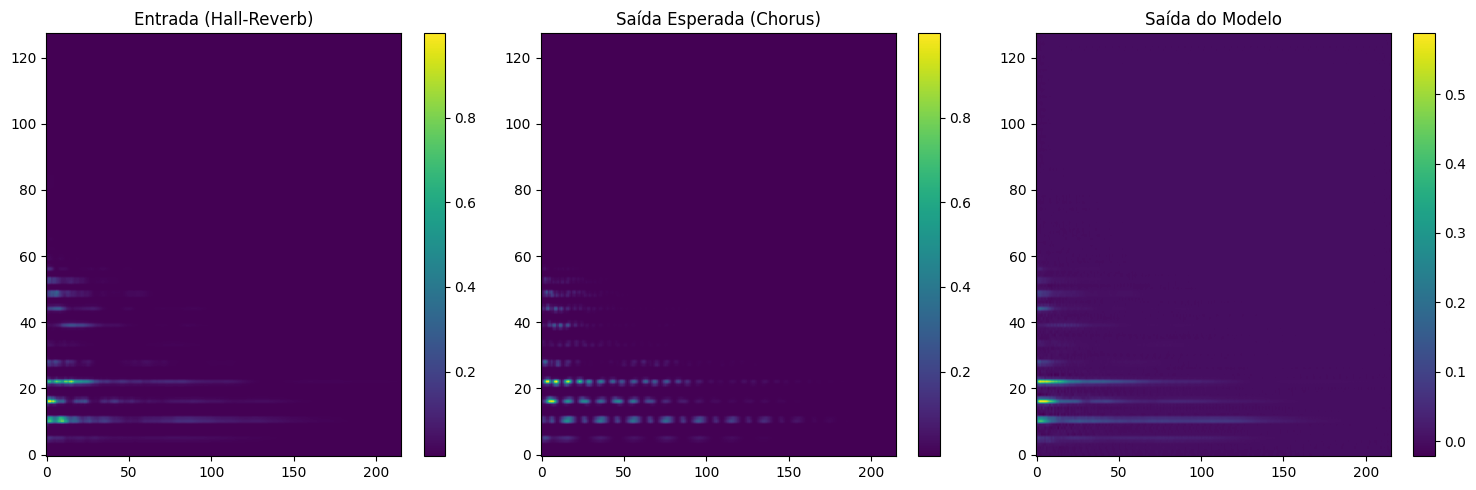

In [71]:
# Visualização de Espectrogramas
def plot_spectrograms(original, target, predicted, index):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Entrada (Hall-Reverb)')
    plt.imshow(original[index].squeeze(), origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title('Saída Esperada (Chorus)')
    plt.imshow(target[index].squeeze(), origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title('Saída do Modelo')
    plt.imshow(predicted[index].squeeze(), origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

plot_spectrograms(input_test, target_test, predicted_specs, index=0)

In [73]:
torch.save(model.state_dict(), 'trained_model.pth')